In [161]:
import matplotlib.pyplot as plt 
import torch 
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from torchvision import transforms
import torchvision
import cv2
import numpy as np
from tqdm.notebook import tqdm
import os
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from scipy.stats import gaussian_kde

In [128]:
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [129]:
device = torch.device("mps")

In [130]:
train_df = pd.read_csv("archive/Training_set.csv")
test_df = pd.read_csv("archive/Testing_set.csv")

In [131]:
le = LabelEncoder()
train_df["label_encoded"] = le.fit_transform(train_df["label"])

num_classes = len(le.classes_)
print(num_classes)

75


In [132]:
train_df.head(3)

,filename,label,label_encoded
0,Image_1.jpg,SOUTHERN DOGFACE,66
1,Image_2.jpg,ADONIS,0
2,Image_3.jpg,BROWN SIPROETA,12


In [133]:
label_dict = {}
for i in range(len(train_df)):
    label = train_df.iloc[i]["label"]
    label_dict[label] = label_dict.get(label, 0) + 1

num_classes = len(label_dict)
print("Number of classes are ", num_classes)

Number of classes are  75


In [134]:
class CustomDataset(Dataset):
    def __init__(self,X, Y, transform=None):
        self.data = X #Dataframe here
        self.labels = Y  #Same
        self.transform = transform

    def __len__(self): #Returns total number of samples
        return len(self.data)

    def __getitem__(self, idx): # 'Lazy loading' logic to load one item at a time 
        img_path = os.path.join("archive", "train", self.data.loc[idx]["filename"])
        image = cv2.imread(img_path)

        label = self.labels.iloc[idx]["label_encoded"]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [189]:
X, Y = train_df, train_df 

train_transforms = transforms.Compose([
    transforms.ToPILImage(), 
    #transforms.CenterCrop()
    transforms.ToTensor()
])

def manual_transform(image):
    image = image.astype(np.float32) / 255.0 
    image = np.transpose(image, (2,0,1))
    return torch.from_numpy(image)

average_scaling_transform = transforms.Compose([
    transforms.ToPILImage(), 
    #transforms.CenterCrop()
    transforms.ToTensor(),
    transforms.Normalize( #ImageNEt mean and std dev values
        mean = [0.485, 0.456, 0.406], 
        std = [0.229, 0.224, 0.225]
    )
])

train_dataset = CustomDataset(X, Y, transform=manual_transform)
#train_dataset = CustomDataset(X, Y, transform=train_transforms)
#train_dataset = CustomDataset(X, Y, transform=average_scaling_transform)

train_loader = DataLoader(
    dataset = train_dataset, 
    batch_size = 64, 
    shuffle = True
)

In [190]:
model = torchvision.models.vgg16(pretrained=True)

for layer in model.parameters():
    layer.requires_grad = False 

In [191]:
input_features_num = model.classifier[-1].in_features
model.classifier[-1] = torch.nn.Linear(input_features_num, num_classes)

for layer in model.classifier:
    layer.requires_grad = True

model = model.to(device)

In [192]:
criterion = torch.nn.CrossEntropyLoss() 
optimizer = torch.optim.SGD(model.classifier.parameters(), lr=0.001)

exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
) #Decay lr schedyler


In [193]:
experiment_name = "no_norm"
def train(
    model, optimizer, 
    loss_function, train_dataloader,
    epochs = 5
):
    for epoch in tqdm(range(epochs)):
        training_loss = 0.0
        training_iterator = 0
        model.train()
        for batch in train_dataloader:
            optimizer.zero_grad()
            inputs, targets = batch 
            inputs, targets = inputs.to(device), targets.to(device)
            output = model(inputs)
            loss = loss_function(output, targets)
            loss.backward()
            optimizer.step()
            training_loss += loss.data.item()
            training_iterator += 1
        weight_value = model.features[0].weight.data.cpu().numpy().flatten()
        history_weights[experiment_name].append(weight_value)
        print(f"Epoch : {epoch} --- Training loss : {training_loss:2f}")



In [194]:
# No norm
train(
    model,
    optimizer, 
    criterion, 
    train_loader,
    epochs=5
)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 0 --- Training loss : 442.679240
Epoch : 1 --- Training loss : 418.461447
Epoch : 2 --- Training loss : 396.691657
Epoch : 3 --- Training loss : 378.845032
Epoch : 4 --- Training loss : 361.031723


In [188]:
# Avg / Standardization

train(
    model,
    optimizer, 
    criterion, 
    train_loader,
    epochs=5
)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 0 --- Training loss : 438.944126
Epoch : 1 --- Training loss : 398.244442
Epoch : 2 --- Training loss : 364.647348
Epoch : 3 --- Training loss : 335.371229
Epoch : 4 --- Training loss : 311.478474


In [181]:
# Min/Max

train(
    model,
    optimizer, 
    criterion, 
    train_loader,
    epochs=5
)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 0 --- Training loss : 443.207965
Epoch : 1 --- Training loss : 418.992100
Epoch : 2 --- Training loss : 396.756889
Epoch : 3 --- Training loss : 378.731541
Epoch : 4 --- Training loss : 361.620416


In [ ]:
# history_weights = {
#     "no_norm" : [], 
#     "mean_norm" : [],
#     "minmax_norm" : []
# }

In [153]:
history_weights["no_norm"][0]

array([-0.00704075, -0.01237132,  0.00223882, ..., -0.02731466,
        0.00525762,  0.02667967], shape=(1179648,), dtype=float32)

In [156]:
df = pd.DataFrame(history_weights)

# Conv Layer - 17

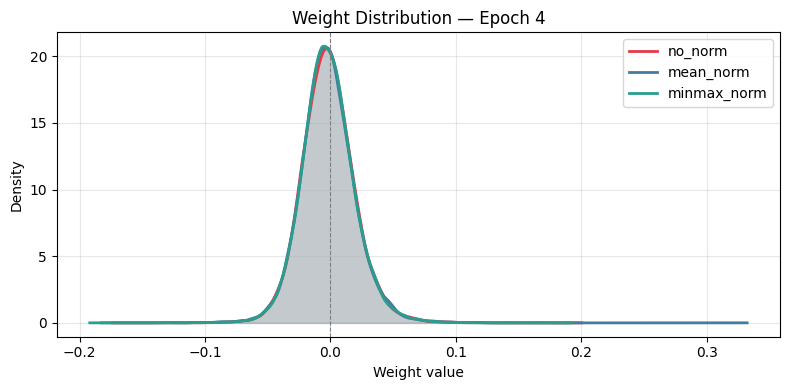

In [173]:
epoch_idx = 3
colors = {"no_norm": "#E63946", "mean_norm": "#457B9D", "minmax_norm": "#2A9D8F"}

fig, ax = plt.subplots(figsize=(8, 4))
for name, arrays in history_weights.items():
    arr = arrays[epoch_idx]
    sample = np.random.choice(arr, 30_000, replace=False)
    kde = gaussian_kde(sample, bw_method=0.15)
    xs = np.linspace(sample.min(), sample.max(), 300)
    ax.plot(xs, kde(xs), color=colors[name], lw=2, label=name)
    ax.fill_between(xs, kde(xs), alpha=0.15, color=colors[name])

ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_title(f"Weight Distribution — Epoch {epoch_idx+1}")
ax.set_xlabel("Weight value"); ax.set_ylabel("Density")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

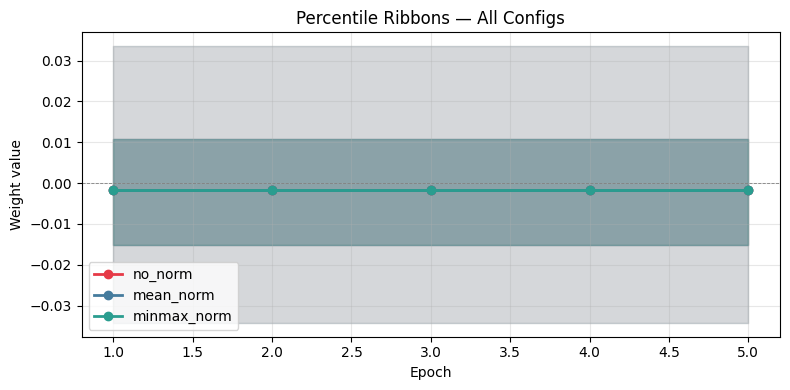

In [166]:
colors = {"no_norm": "#E63946", "mean_norm": "#457B9D", "minmax_norm": "#2A9D8F"}

fig, ax = plt.subplots(figsize=(8, 4))
for name, arrays in history_weights.items():
    c = colors[name]
    epochs = range(1, len(arrays)+1)
    p5   = [np.percentile(a, 5)  for a in arrays]
    p95  = [np.percentile(a, 95) for a in arrays]
    p25  = [np.percentile(a, 25) for a in arrays]
    p75  = [np.percentile(a, 75) for a in arrays]
    mean = [np.mean(a)            for a in arrays]

    ax.fill_between(epochs, p5, p95, alpha=0.10, color=c)
    ax.fill_between(epochs, p25, p75, alpha=0.25, color=c)
    ax.plot(epochs, mean, color=c, marker="o", lw=2, label=name)

ax.axhline(0, color="gray", lw=0.6, ls="--")
ax.set_title("Percentile Ribbons — All Configs")
ax.set_xlabel("Epoch"); ax.set_ylabel("Weight value")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

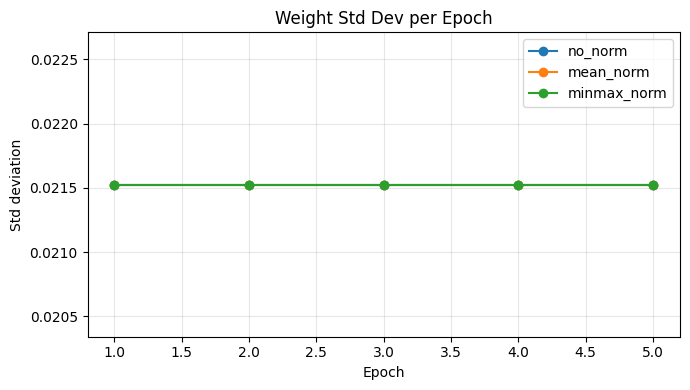

In [167]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, arrays in history_weights.items():
    stds = [np.std(arr) for arr in arrays]
    ax.plot(range(1, len(stds)+1), stds, marker="o", label=name)

ax.set_title("Weight Std Dev per Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Std deviation")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

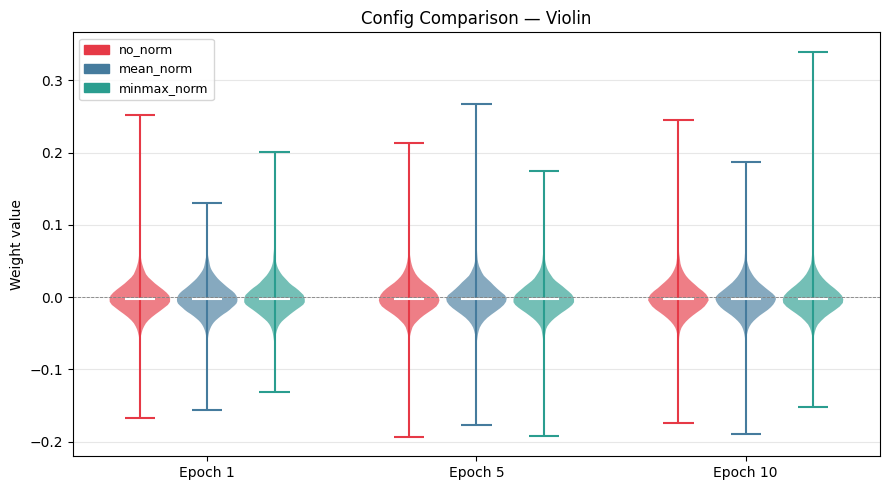

In [168]:
epochs_to_show = [0, 2, 4]   # epoch 1, 5, 10
config_names = list(history_weights.keys())
colors = ["#E63946", "#457B9D", "#2A9D8F"]
x_base = np.array([1, 2, 3])   # x positions per epoch group
width  = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, color) in enumerate(zip(config_names, colors)):
    for j, ep_idx in enumerate(epochs_to_show):
        sample = np.random.choice(history_weights[name][ep_idx], 20_000, replace=False)
        pos = x_base[j] + (i - 1) * width   # offset each config side by side
        parts = ax.violinplot(sample, positions=[pos], widths=width*0.9, showmedians=True)
        for pc in parts["bodies"]:
            pc.set_facecolor(color); pc.set_alpha(0.65)
        parts["cmedians"].set_color("white")
        for key in ["cbars", "cmins", "cmaxes"]:
            parts[key].set_color(color)

# Legend proxies
from matplotlib.patches import Patch
ax.legend([Patch(color=c) for c in colors], config_names, fontsize=9)
ax.set_xticks(x_base)
ax.set_xticklabels(["Epoch 1", "Epoch 5", "Epoch 10"])
ax.axhline(0, color="gray", lw=0.6, ls="--")
ax.set_title("Config Comparison — Violin"); ax.set_ylabel("Weight value")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

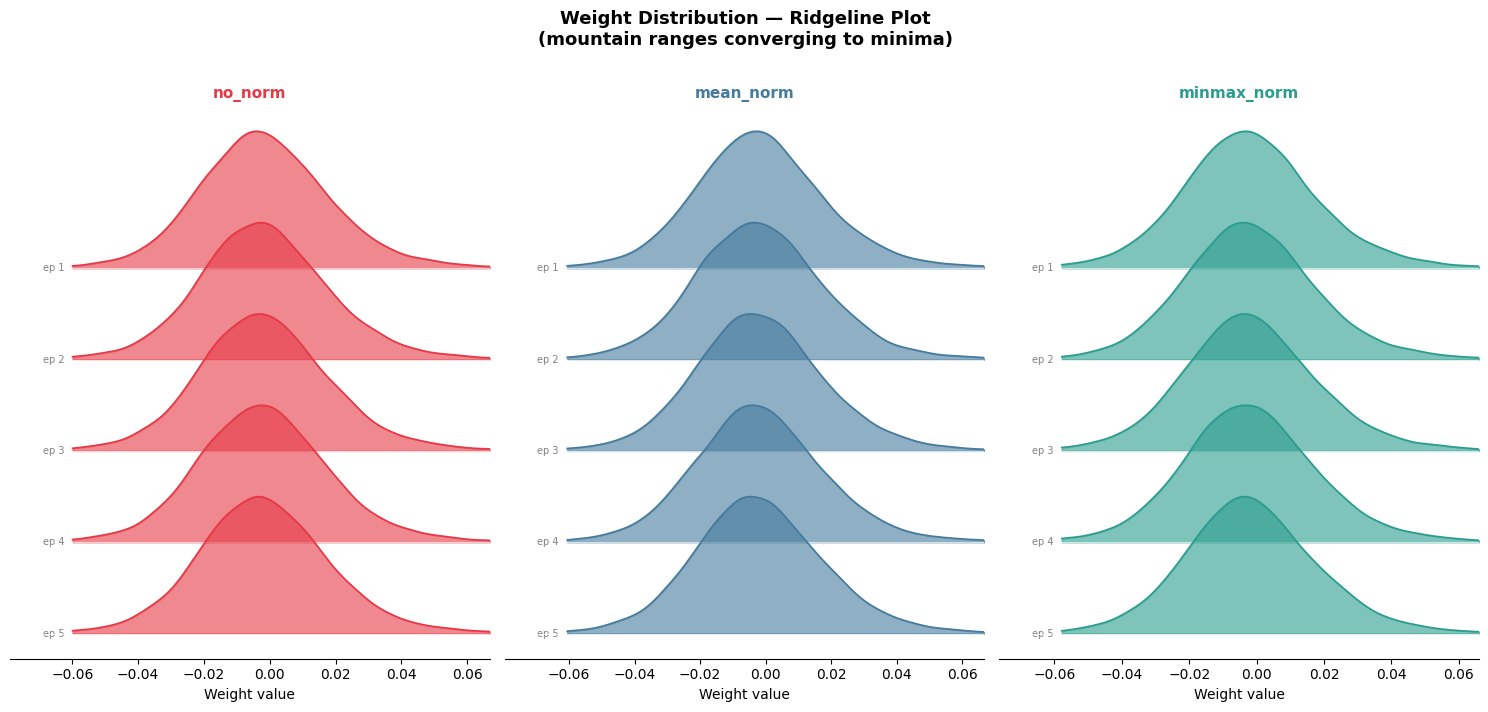

In [171]:
colors = {"no_norm": "#E63946", "mean_norm": "#457B9D", "minmax_norm": "#2A9D8F"}

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
overlap = 1.5   # how much ridges overlap — increase for more dramatic effect

for ax, (name, arrays) in zip(axes, history_weights.items()):
    n_epochs = len(arrays)
    
    # shared x range across all epochs for this config
    all_sample = np.concatenate([np.random.choice(a, 5_000, replace=False) for a in arrays])
    xs = np.linspace(np.percentile(all_sample, 0.5), np.percentile(all_sample, 99.5), 300)
    
    color = colors[name]
    
    for i, arr in enumerate(arrays):
        sample = np.random.choice(arr, 30_000, replace=False)
        kde = gaussian_kde(sample, bw_method=0.15)
        ys  = kde(xs)
        ys  = ys / ys.max()   # normalize height so overlap is consistent
        
        baseline = n_epochs - i   # top epoch at highest position
        
        ax.fill_between(xs, baseline, baseline + ys * overlap,
                        color=color, alpha=0.6, zorder=i)
        ax.plot(xs, baseline + ys * overlap,
                color=color, lw=1.2, zorder=i)
        ax.axhline(baseline, color="white", lw=0.5, zorder=i)
        ax.text(xs[0] - (xs[-1]-xs[0])*0.02, baseline, f"ep {i+1}",
                va="center", ha="right", fontsize=7, color="gray")

    ax.set_title(name, fontsize=11, fontweight="bold", color=color)
    ax.set_xlabel("Weight value")
    ax.set_xlim(xs[0] - (xs[-1]-xs[0])*0.15, xs[-1])
    ax.set_yticks([])
    ax.spines[["left","right","top"]].set_visible(False)

plt.suptitle("Weight Distribution — Ridgeline Plot\n(mountain ranges converging to minima)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Conv Layer 0

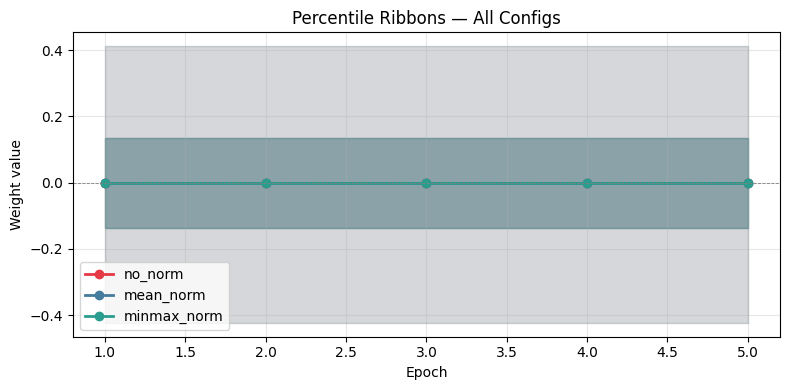

In [198]:
colors = {"no_norm": "#E63946", "mean_norm": "#457B9D", "minmax_norm": "#2A9D8F"}

fig, ax = plt.subplots(figsize=(8, 4))
for name, arrays in history_weights.items():
    c = colors[name]
    epochs = range(1, len(arrays)+1)
    p5   = [np.percentile(a, 5)  for a in arrays]
    p95  = [np.percentile(a, 95) for a in arrays]
    p25  = [np.percentile(a, 25) for a in arrays]
    p75  = [np.percentile(a, 75) for a in arrays]
    mean = [np.mean(a)            for a in arrays]

    ax.fill_between(epochs, p5, p95, alpha=0.10, color=c)
    ax.fill_between(epochs, p25, p75, alpha=0.25, color=c)
    ax.plot(epochs, mean, color=c, marker="o", lw=2, label=name)

ax.axhline(0, color="gray", lw=0.6, ls="--")
ax.set_title("Percentile Ribbons — All Configs")
ax.set_xlabel("Epoch"); ax.set_ylabel("Weight value")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

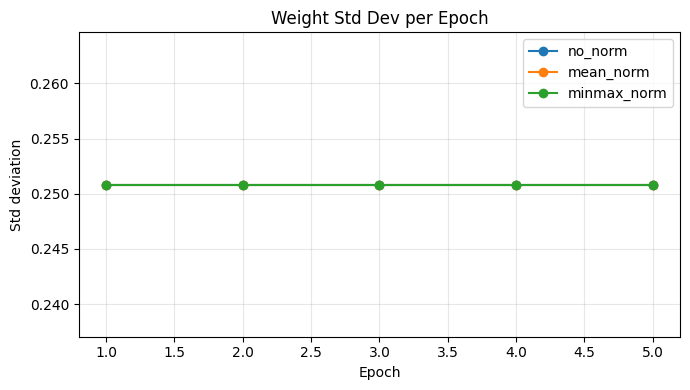

In [199]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, arrays in history_weights.items():
    stds = [np.std(arr) for arr in arrays]
    ax.plot(range(1, len(stds)+1), stds, marker="o", label=name)

ax.set_title("Weight Std Dev per Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Std deviation")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Note 
* Lower layer (17) did not show much difference in the distributions - updated slowly ? Gradient flow not affected much ?
